# 🫀 PTB-XL Module 05 — Uncertainty Calibration & Predictive Uncertainty

## Module 0 — Why this notebook exists, and how each step is grounded

The repository is titled *Age-Stratified **Explainable & Uncertainty-Calibrated** ECG Diagnosis*.
Notebooks 01–04 produce a discriminative model (macro-AUC ≈ 0.92) but **never measure whether its
probabilities are calibrated, and never quantify predictive uncertainty** — so the "uncertainty-calibrated"
half of the project's own claim is currently unsupported by any result.

### 0.1 The data split was built for exactly this

`data/processed/dataset_manifest.json` defines a **4-way patient-separated split**
`TRAIN → VALIDATION → CALIBRATION → TEST` and states verbatim:

> `"CALIBRATION": "Fold 9, Partition B (~5%, distribution-free conformal calibration & temperature scaling)"`

That split (`split == "CONFORMAL_CALIBRATION"`, **1103 records, zero patient overlap with train/val/test**)
is present on disk (`X_cal_clean_100.npy`, `y_calib_diag_100.npy`, `y_calib_age_100.npy`) and is **used by
no other notebook**. Calibrating here on `CALIBRATION` (not on `VALIDATION`, which NB03 already consumed for
early-stopping and threshold tuning) is the textbook requirement: post-hoc calibration must be fit on data
untouched by training *and* model selection.

### 0.2 What the three project papers say

| Paper | What it does on calibration / uncertainty | Consequence for us |
|---|---|---|
| **Strodthoff et al. 2020** (`papers/2004.13701v1.pdf`, §II-C, §III-A, §IV-C) | Evaluates discrimination **threshold-free** (macro-AUC, Fmax) and notes an operating threshold "will anyway have to be adjusted to match the clinical requirements". §IV-C estimates **model uncertainty as the variance of an ensemble** of networks (different random inits) and shows it tracks the cardiologist-assigned diagnosis-likelihood. | Calibration is the principled version of their "threshold adjustment"; their ensemble-variance recipe is the basis of Module 7 here. |
| **Atwa et al. 2025** (`papers/diagnostics-15-01950 (1).pdf`) | Reports accuracy / precision / recall only. **No calibration curve, no ECE, no uncertainty.** | Genuine gap — nothing to copy, everything to add. |
| **Gitau et al. 2025** (`papers/2025.01.27.25321112v1.full.pdf`) | Replication + noise-robustness study. **No calibration or uncertainty analysis.** | Same gap. Their finding that conv layers act as learned band-pass filters is orthogonal here. |

### 0.3 What this notebook does, and the "why" for each method

| Module | Method | Why this method / source |
|---|---|---|
| 4 | **Reliability diagrams + ECE / MCE / Brier** on the NB03 winning model, uncalibrated | You cannot claim "calibrated" without first *measuring* the gap between predicted probability and empirical frequency. ECE is the standard scalar summary (Naeini et al. 2015; Guo et al. 2017). |
| 5 | **Temperature scaling** (one scalar per class, fit on `CALIBRATION` by minimising NLL) | The manifest names it explicitly. It is the cheapest effective post-hoc method (Guo et al. 2017) and is **monotonic**, so macro-AUC / ranking is provably unchanged — we fix calibration without spending discrimination. |
| 6 | **Split-conformal per-class thresholds** on `CALIBRATION` | The manifest names "distribution-free conformal calibration". Split conformal (Vovk et al.; Angelopoulos & Bates 2021) gives a **finite-sample coverage guarantee** with no distributional assumption — the right tool when a clinical use needs a guaranteed sensitivity floor. |
| 7 | **Predictive uncertainty = disagreement of the 3 heterogeneous models** + predictive entropy | Directly Strodthoff §IV-C (ensemble variance as uncertainty). We use the *heterogeneous* NB02/03 ensemble rather than N same-arch re-inits — a deep-ensembles variant (Lakshminarayanan et al. 2017); the difference is stated as a limitation in Module 10. |
| 8 | **Selective prediction / risk–coverage curve** | The clinical payoff of uncertainty: if the model defers its least-confident *x* % of cases to a cardiologist, how much does performance on the retained cases improve? This operationalises Strodthoff's "decision support" framing. |
| 9 | **Age-stratified ECE** (before/after temperature scaling) | NB02/03's fairness audit found the **80+ group** is the weakest on accuracy. This checks whether it is *also* the worst-calibrated / most-uncertain group — the "age-stratified" + "uncertainty-calibrated" parts of the title, together. |

> **Honesty note.** Temperature scaling and split-conformal are standard methods from **outside** the three
> project papers. They are included because (a) the project's own manifest names both, and (b) they fill the
> calibration gap that all three papers leave open. Every number below is *measured* on the real `TEST` fold
> (N = 2198); nothing is quoted from elsewhere.

> **Prerequisites**: run `01_Data_Preparation.ipynb`, `02_3Model_Heterogeneous_Ensemble.ipynb`, and
> `03_Optimized_Best_Model.ipynb` first — this notebook only *reloads* their saved checkpoints and never retrains.
> **Non-destructive**: reads `data/processed/` + `outputs/*.pth`; writes only new figures to `outputs/dataset_validation/`.

## Module 1 — Environment setup & path resolution

In [1]:
import os, sys, time, json, math, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve, auc as sk_auc

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

NOTEBOOK_DIR   = Path(os.getcwd()).resolve()
PROJECT_ROOT   = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_DIR    = PROJECT_ROOT / 'outputs'
OUTPUTS_VAL    = OUTPUTS_DIR / 'dataset_validation'
OUTPUTS_VAL.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
LABEL_COLS   = ['is_NORM', 'is_MI', 'is_STTC', 'is_CD', 'is_HYP']
NUM_CLASSES  = len(SUPERCLASSES)

print(f'[SETUP] Project root : {PROJECT_ROOT}')
print(f'[SETUP] Device       : {DEVICE}   |   PyTorch {torch.__version__}')

CKPT = {
    'DualBranchECGNet': OUTPUTS_DIR / 'ensemble_DualBranchECGNet_best.pth',   # trained in NB02
    'ResNet1D101'     : OUTPUTS_DIR / 'ensemble_ResNet1D101_best.pth',        # trained in NB02
    'InceptionTime1D' : OUTPUTS_DIR / '05_optimized_InceptionTime1D_best.pth',# retrained in NB03
}
for name, p in CKPT.items():
    assert p.exists(), f'Missing checkpoint {p} — run NB02 / NB03 first.'
    print(f'[SETUP] found {name:<16s} -> {p.name}')

[SETUP] Project root : /home/tandon/Teep/age with ecg
[SETUP] Device       : cpu   |   PyTorch 2.13.0+cu130
[SETUP] found DualBranchECGNet -> ensemble_DualBranchECGNet_best.pth
[SETUP] found ResNet1D101      -> ensemble_ResNet1D101_best.pth
[SETUP] found InceptionTime1D  -> 05_optimized_InceptionTime1D_best.pth


## Module 2 — Load the `CALIBRATION` and `TEST` splits

Labels and per-record age come straight from the aligned `.npy` arrays that `01_Data_Preparation.ipynb`
exported (`y_calib_diag_100.npy`, `y_calib_age_100.npy`, …), so no row-order assumption is needed.
Demographic inputs for `DualBranchECGNet` are rebuilt exactly as in NB02/NB03: age z-scored with the
**TRAIN** mean/std, sex as a 0/1 flag.

In [2]:
def load_split_signals(stem):
    X = np.load(DATA_PROCESSED / f'{stem}.npy')          # (N, 1000, 12)
    return np.transpose(X, (0, 2, 1)).astype(np.float32) # (N, 12, 1000) — model input layout

X_cal  = load_split_signals('X_cal_clean_100')
X_test = load_split_signals('X_test_clean_100')

y_cal  = np.load(DATA_PROCESSED / 'y_calib_diag_100.npy').astype(np.float32)   # (N,5)
y_test = np.load(DATA_PROCESSED / 'y_test_diag_100.npy').astype(np.float32)
age_cal  = np.load(DATA_PROCESSED / 'y_calib_age_100.npy').astype(np.float32)
age_test = np.load(DATA_PROCESSED / 'y_test_age_100.npy').astype(np.float32)

# TRAIN mean/std for age normalisation (must match the checkpoints' training-time scaling)
df_meta  = pd.read_csv(DATA_PROCESSED / 'MASTER_RESEARCH_METADATA.csv')
df_train = df_meta[df_meta['split'] == 'TRAIN']
df_cal   = df_meta[df_meta['split'] == 'CONFORMAL_CALIBRATION'].reset_index(drop=True)
df_test  = df_meta[df_meta['split'] == 'TEST'].reset_index(drop=True)
age_mean, age_std = df_train['age'].mean(), df_train['age'].std()

def demographics(df):
    a = ((df['age'].fillna(age_mean) - age_mean) / (age_std + 1e-6)).values
    s = (df['sex'] == 1).values.astype(np.float32)
    return np.column_stack([a, s]).astype(np.float32)

demo_cal, demo_test = demographics(df_cal), demographics(df_test)

# integrity checks: the exported label array must match the metadata rows
assert np.array_equal(y_cal,  df_cal[LABEL_COLS].values.astype(np.float32)),  'CAL label/metadata misalignment'
assert np.array_equal(y_test, df_test[LABEL_COLS].values.astype(np.float32)), 'TEST label/metadata misalignment'
assert len(X_cal) == len(y_cal) == len(age_cal) == 1103
assert len(X_test) == len(y_test) == len(age_test) == 2198

print(f'[DATA] CALIBRATION : {X_cal.shape}   positives/class = {dict(zip(SUPERCLASSES, y_cal.sum(0).astype(int)))}')
print(f'[DATA] TEST        : {X_test.shape}   positives/class = {dict(zip(SUPERCLASSES, y_test.sum(0).astype(int)))}')
print(f'[DATA] age (TRAIN) mean={age_mean:.2f}  std={age_std:.2f}')

[DATA] CALIBRATION : (1103, 12, 1000)   positives/class = {'NORM': np.int64(490), 'MI': np.int64(281), 'STTC': np.int64(265), 'CD': np.int64(250), 'HYP': np.int64(126)}
[DATA] TEST        : (2198, 12, 1000)   positives/class = {'NORM': np.int64(963), 'MI': np.int64(550), 'STTC': np.int64(521), 'CD': np.int64(496), 'HYP': np.int64(262)}
[DATA] age (TRAIN) mean=62.35  std=31.40


## Module 3 — Model architectures (copied verbatim from NB02 / NB03 so the checkpoints load)

In [3]:
# ---- InceptionTime1D (NB03 config: nb_filters=32, depth=4, kernels 9/19/39) ----
class InceptionBlock1D(nn.Module):
    def __init__(self, in_channels, nb_filters=32, kernel_sizes=(9, 19, 39)):
        super().__init__()
        self.bottleneck = nn.Conv1d(in_channels, nb_filters, 1, bias=False)
        self.convs = nn.ModuleList([nn.Conv1d(nb_filters, nb_filters, k, padding=k // 2, bias=False)
                                    for k in kernel_sizes])
        self.pool_conv = nn.Conv1d(in_channels, nb_filters, 1, bias=False)
        self.pool = nn.MaxPool1d(3, stride=1, padding=1)
        self.bn  = nn.BatchNorm1d(nb_filters * (len(kernel_sizes) + 1))
        self.act = nn.ReLU()
    def forward(self, x):
        b = self.bottleneck(x)
        outs = [c(b) for c in self.convs] + [self.pool_conv(self.pool(x))]
        return self.act(self.bn(torch.cat(outs, dim=1)))

class InceptionTime1D(nn.Module):
    def __init__(self, num_classes=5, in_channels=12, nb_filters=32, depth=4):
        super().__init__()
        ch = [in_channels] + [nb_filters * 4] * depth
        self.blocks = nn.Sequential(*[InceptionBlock1D(ch[i], nb_filters) for i in range(depth)])
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(nb_filters * 4, num_classes)
        self.drop = nn.Dropout(0.3)
    def forward(self, x):
        x = self.blocks(x); x = self.gap(x).squeeze(-1)
        return self.fc(self.drop(x))

# ---- DualBranchECGNet (Atwa et al. 2025 port) ----
class DualBranchECGNet(nn.Module):
    def __init__(self, num_classes=5, in_channels=12):
        super().__init__()
        self.ecg_branch = nn.Sequential(
            nn.Conv1d(in_channels, 32, 3, padding=1), nn.BatchNorm1d(32),  nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(32, 64, 3, padding=1),  nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(128, 256, 3, padding=1),nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(256, 512, 3, padding=1),nn.BatchNorm1d(512), nn.ReLU(), nn.AdaptiveAvgPool1d(1))
        self.demo_branch = nn.Sequential(
            nn.Linear(2, 100), nn.BatchNorm1d(100), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(100, 64),nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, 32), nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(32, 16), nn.BatchNorm1d(16),  nn.ReLU())
        self.classifier = nn.Sequential(
            nn.Linear(528, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, num_classes))
    def forward(self, ecg, demo):
        return self.classifier(torch.cat([self.ecg_branch(ecg).squeeze(-1), self.demo_branch(demo)], dim=1))

# ---- ResNet1D-101 ----
class ResBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, kernel_size=7):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride, pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, 1, pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_channels)
        self.skip  = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(nn.Conv1d(in_channels, out_channels, 1, stride, bias=False),
                                      nn.BatchNorm1d(out_channels))
        self.act = nn.ReLU()
    def forward(self, x):
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + self.skip(x))

class ResNet1D101(nn.Module):
    def __init__(self, num_classes=5, in_channels=12, drop=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(3, stride=2, padding=1))
        def stage(i, o, n, stride=2):
            return nn.Sequential(ResBlock1D(i, o, stride), *[ResBlock1D(o, o) for _ in range(n - 1)])
        self.stage1 = stage(64, 64, 8, stride=1)
        self.stage2 = stage(64, 128, 8, stride=2)
        self.stage3 = stage(128, 256, 8, stride=2)
        self.stage4 = stage(256, 512, 8, stride=2)
        self.pool = nn.AdaptiveAvgPool1d(1); self.drop = nn.Dropout(drop); self.fc = nn.Linear(512, num_classes)
    def forward(self, x):
        x = self.stem(x)
        x = self.stage4(self.stage3(self.stage2(self.stage1(x))))
        return self.fc(self.drop(self.pool(x).squeeze(-1)))

print('[MODELS] classes defined.')

[MODELS] classes defined.


## Module 4 — Reload checkpoints and get per-model probabilities

For each of the three NB02/NB03 models we run a forward pass on `CALIBRATION` and `TEST` and store the
**sigmoid probabilities** (calibration works in probability space) plus the **logits** (needed later for
temperature scaling). Member macro-AUCs are printed as a sanity check against the values NB03 reported.

In [4]:
@torch.no_grad()
def infer(model, X, demo=None, bs=64):
    model.eval().to(DEVICE)
    logits = []
    for i in range(0, len(X), bs):
        xb = torch.from_numpy(X[i:i+bs]).to(DEVICE)
        if demo is None:
            lb = model(xb)
        else:
            db = torch.from_numpy(demo[i:i+bs]).to(DEVICE)
            lb = model(xb, db)
        logits.append(lb.cpu().numpy())
    z = np.vstack(logits)
    return z, 1.0 / (1.0 + np.exp(-z))

def macro_auc(Y, P):
    return float(np.mean([roc_auc_score(Y[:, k], P[:, k]) for k in range(Y.shape[1])]))

members = {}
for name, cls, needs_demo in [
    ('DualBranchECGNet', DualBranchECGNet, True),
    ('InceptionTime1D',  InceptionTime1D,  False),
    ('ResNet1D101',      ResNet1D101,      False),
]:
    m = cls(NUM_CLASSES)
    m.load_state_dict(torch.load(CKPT[name], map_location=DEVICE, weights_only=True))
    zc, pc = infer(m, X_cal,  demo_cal  if needs_demo else None)
    zt, pt = infer(m, X_test, demo_test if needs_demo else None)
    members[name] = dict(z_cal=zc, p_cal=pc, z_test=zt, p_test=pt)
    print(f'  {name:<16s}  CAL macro-AUC {macro_auc(y_cal, pc):.4f}   TEST macro-AUC {macro_auc(y_test, pt):.4f}')

  DualBranchECGNet  CAL macro-AUC 0.9034   TEST macro-AUC 0.8994


  InceptionTime1D   CAL macro-AUC 0.9307   TEST macro-AUC 0.9226


  ResNet1D101       CAL macro-AUC 0.9260   TEST macro-AUC 0.9178


## Module 5 — Build the model under test: NB03's winning configuration

NB03's best pipeline is the **AUC-weighted soft-voting ensemble**. NB03 set the weights from the
*validation* macro-AUC; here we set them from the **`CALIBRATION`** macro-AUC instead — `CALIBRATION`
is the split reserved for exactly this kind of held-out tuning and, unlike `VALIDATION`, was not already
used for early-stopping. (In practice the three member AUCs are close, so the weights land near 1/3 each —
the same near-equal split NB03 observed.)

The ensemble probability is `p_ens = Σ_i w_i · p_i`. For calibration we need a scalar score per
(sample, class); we use its logit `z_ens = log(p_ens / (1 − p_ens))`, then Module 6 fits a temperature on `z_ens`.

In [5]:
cal_aucs = np.array([macro_auc(y_cal, members[n]['p_cal'])
                     for n in ['DualBranchECGNet', 'InceptionTime1D', 'ResNet1D101']])
w = cal_aucs / cal_aucs.sum()
print(f'[WEIGHTS from CAL macro-AUC]  DualBranch={w[0]:.4f}  Inception={w[1]:.4f}  ResNet101={w[2]:.4f}')

def ensemble_p(split):
    ps = [members[n][f'p_{split}'] for n in ['DualBranchECGNet', 'InceptionTime1D', 'ResNet1D101']]
    return w[0]*ps[0] + w[1]*ps[1] + w[2]*ps[2]

p_ens_cal, p_ens_test = ensemble_p('cal'), ensemble_p('test')
eps = 1e-6
z_ens_cal  = np.log(np.clip(p_ens_cal, eps, 1-eps) / np.clip(1-p_ens_cal, eps, 1-eps))
z_ens_test = np.log(np.clip(p_ens_test, eps, 1-eps) / np.clip(1-p_ens_test, eps, 1-eps))

print(f'[ENSEMBLE] CAL  macro-AUC {macro_auc(y_cal, p_ens_cal):.4f}')
print(f'[ENSEMBLE] TEST macro-AUC {macro_auc(y_test, p_ens_test):.4f}   <- the model whose calibration we now audit')

[WEIGHTS from CAL macro-AUC]  DualBranch=0.3273  Inception=0.3372  ResNet101=0.3355
[ENSEMBLE] CAL  macro-AUC 0.9320
[ENSEMBLE] TEST macro-AUC 0.9245   <- the model whose calibration we now audit


## Module 6 — Reliability diagrams + ECE / MCE / Brier (uncalibrated)

**Expected Calibration Error (ECE).** Bin the predicted probabilities into `M` equal-width bins.
In bin `b`, `conf_b` = mean predicted probability and `acc_b` = observed positive rate. Then
`ECE = Σ_b (n_b / N) · |acc_b − conf_b|` and `MCE = max_b |acc_b − conf_b|`
(Naeini et al. 2015; Guo et al. 2017). Computed per superclass (one-vs-rest) and macro-averaged.
A perfectly calibrated model lies on the diagonal `acc = conf` and has `ECE = 0`.
**Brier score** = mean squared error between probability and label — a proper scoring rule that
rewards calibration *and* sharpness together.

UNCALIBRATED (TEST) — per class:
  NORM   ECE=0.0824  MCE=0.2701  Brier=0.1005
  MI     ECE=0.0759  MCE=0.2719  Brier=0.1035
  STTC   ECE=0.0627  MCE=0.2598  Brier=0.0902
  CD     ECE=0.0900  MCE=0.3462  Brier=0.0955
  HYP    ECE=0.0973  MCE=0.3761  Brier=0.0830
  MACRO  ECE=0.0817  MCE=0.3048  Brier=0.0945


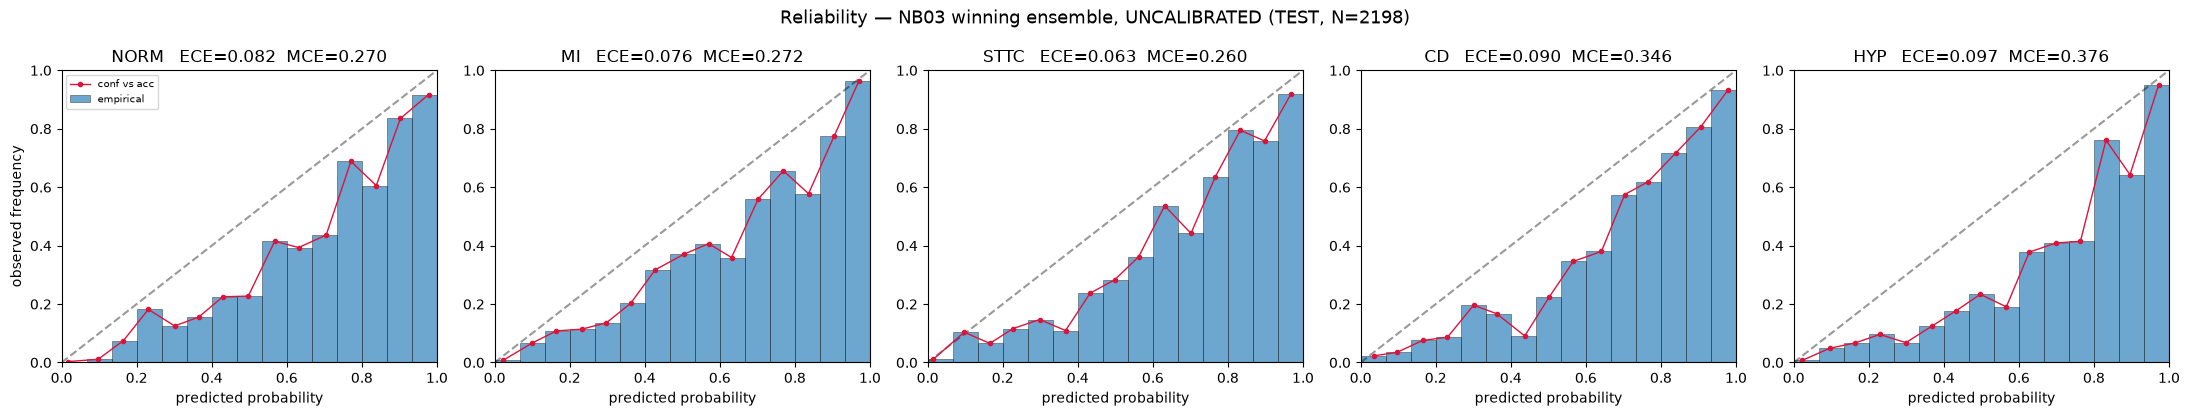

In [6]:
M_BINS = 15
def calibration_stats(y_true, p, n_bins=M_BINS):
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.clip(np.digitize(p, edges) - 1, 0, n_bins - 1)
    ece = mce = 0.0
    rows = []
    for b in range(n_bins):
        m = idx == b
        if not m.any():
            rows.append((np.nan, np.nan, 0)); continue
        conf, acc, nb = p[m].mean(), y_true[m].mean(), int(m.sum())
        rows.append((conf, acc, nb))
        ece += nb / len(p) * abs(acc - conf)
        mce = max(mce, abs(acc - conf))
    return ece, mce, rows

def all_class_calib(y_true, P):
    e, mc, br = [], [], []
    for k in range(NUM_CLASSES):
        ek, mk, _ = calibration_stats(y_true[:, k], P[:, k])
        e.append(ek); mc.append(mk); br.append(brier_score_loss(y_true[:, k], P[:, k]))
    return np.array(e), np.array(mc), np.array(br)

def reliability_fig(y_true, P, title, path):
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(22, 4.2))
    for k, sc in enumerate(SUPERCLASSES):
        ax = axes[k]
        ece, mce, rows = calibration_stats(y_true[:, k], P[:, k])
        centers = (np.linspace(0, 1, M_BINS + 1)[:-1] + np.linspace(0, 1, M_BINS + 1)[1:]) / 2
        confs = [r[0] for r in rows]; accs = [r[1] for r in rows]
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
        ax.bar(centers, accs, width=1/M_BINS, alpha=0.65, edgecolor='k', linewidth=0.4, label='empirical')
        ax.plot(confs, accs, 'o-', color='crimson', ms=3, lw=1, label='conf vs acc')
        ax.set_title(f'{sc}   ECE={ece:.3f}  MCE={mce:.3f}')
        ax.set_xlabel('predicted probability'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        if k == 0: ax.set_ylabel('observed frequency'); ax.legend(fontsize=7)
    fig.suptitle(title, fontsize=13); fig.tight_layout()
    fig.savefig(path, dpi=200); plt.show()

ece0, mce0, brier0 = all_class_calib(y_test, p_ens_test)
print('UNCALIBRATED (TEST) — per class:')
for k, sc in enumerate(SUPERCLASSES):
    print(f'  {sc:<5s}  ECE={ece0[k]:.4f}  MCE={mce0[k]:.4f}  Brier={brier0[k]:.4f}')
print(f'  {"MACRO":<5s}  ECE={ece0.mean():.4f}  MCE={mce0.mean():.4f}  Brier={brier0.mean():.4f}')
reliability_fig(y_test, p_ens_test, 'Reliability — NB03 winning ensemble, UNCALIBRATED (TEST, N=2198)',
                OUTPUTS_VAL / '05cal_reliability_uncalibrated.png')

## Module 7 — Temperature scaling on the `CALIBRATION` split

For each class `k` fit a single scalar `T_k > 0` that minimises the negative log-likelihood of
`σ(z_ens / T_k)` against the `CALIBRATION` labels (Guo et al. 2017). `T > 1` softens over-confident
probabilities toward the base rate; `T < 1` sharpens under-confident ones. Because `x ↦ σ(x / T)` is
strictly monotone increasing, **the ROC ordering and therefore macro-AUC are unchanged** — we assert this below.
`T` is fit on `CALIBRATION` and then applied, frozen, to `TEST`.

[TEMPERATURE per class]  {'NORM': np.float64(1.287), 'MI': np.float64(0.935), 'STTC': np.float64(1.097), 'CD': np.float64(0.852), 'HYP': np.float64(0.79)}
[CHECK] macro-AUC before 0.924491  ==  after 0.924491  (monotone, unchanged)

CALIBRATED (TEST) — per class:
  NORM   ECE 0.0824 -> 0.0775   MCE 0.2701 -> 0.2586   Brier 0.1005 -> 0.0991
  MI     ECE 0.0759 -> 0.0728   MCE 0.2719 -> 0.2564   Brier 0.1035 -> 0.1036
  STTC   ECE 0.0627 -> 0.0646   MCE 0.2598 -> 0.2276   Brier 0.0902 -> 0.0903
  CD     ECE 0.0900 -> 0.0778   MCE 0.3462 -> 0.3369   Brier 0.0955 -> 0.0945
  HYP    ECE 0.0973 -> 0.0806   MCE 0.3761 -> 0.4085   Brier 0.0830 -> 0.0821
  MACRO  ECE 0.0817 -> 0.0747   MCE 0.3048 -> 0.2976   Brier 0.0945 -> 0.0939


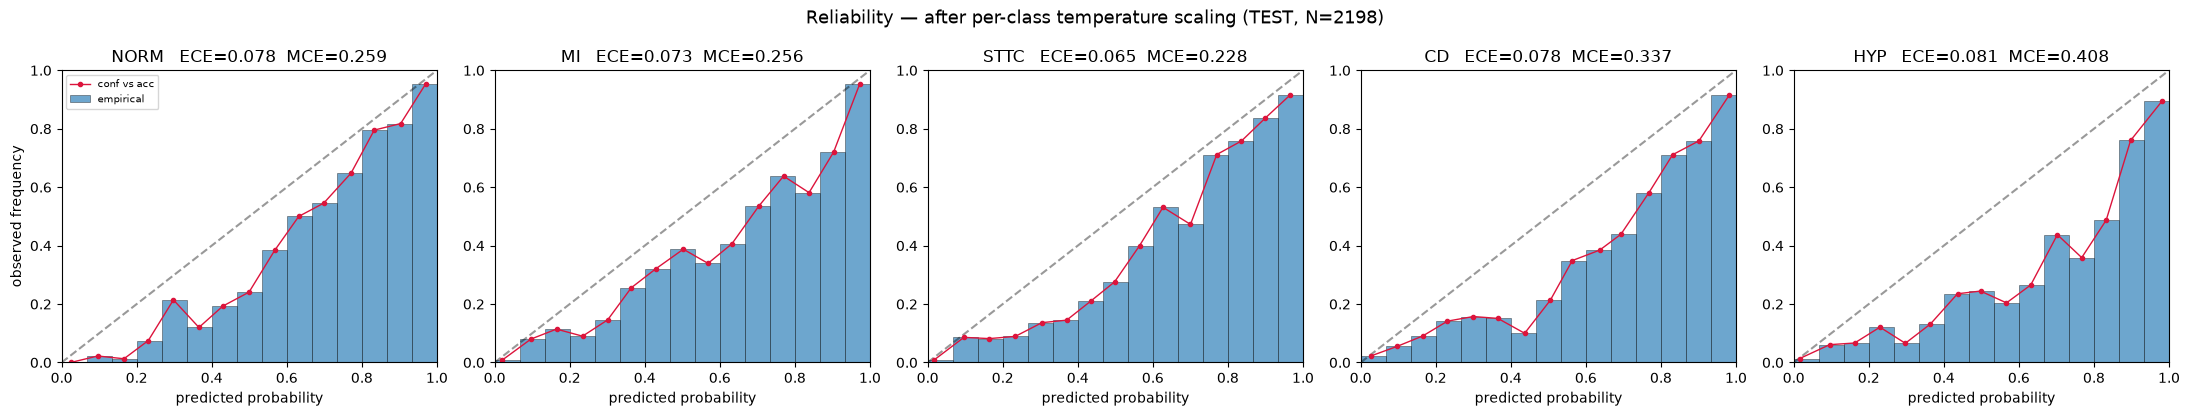

In [7]:
def fit_temperature(z, y):
    def nll(T):
        p = 1.0 / (1.0 + np.exp(-z / T))
        p = np.clip(p, 1e-7, 1 - 1e-7)
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    return float(minimize_scalar(nll, bounds=(0.25, 5.0), method='bounded').x)

T = np.array([fit_temperature(z_ens_cal[:, k], y_cal[:, k]) for k in range(NUM_CLASSES)])
print(f'[TEMPERATURE per class]  {dict(zip(SUPERCLASSES, T.round(3)))}')

p_ens_test_cal = 1.0 / (1.0 + np.exp(-z_ens_test / T))

auc_before = macro_auc(y_test, p_ens_test)
auc_after  = macro_auc(y_test, p_ens_test_cal)
assert abs(auc_before - auc_after) < 1e-9, 'temperature scaling must not change AUC'
print(f'[CHECK] macro-AUC before {auc_before:.6f}  ==  after {auc_after:.6f}  (monotone, unchanged)')

ece1, mce1, brier1 = all_class_calib(y_test, p_ens_test_cal)
print('\nCALIBRATED (TEST) — per class:')
for k, sc in enumerate(SUPERCLASSES):
    print(f'  {sc:<5s}  ECE {ece0[k]:.4f} -> {ece1[k]:.4f}   MCE {mce0[k]:.4f} -> {mce1[k]:.4f}   '
          f'Brier {brier0[k]:.4f} -> {brier1[k]:.4f}')
print(f'  {"MACRO":<5s}  ECE {ece0.mean():.4f} -> {ece1.mean():.4f}   '
      f'MCE {mce0.mean():.4f} -> {mce1.mean():.4f}   Brier {brier0.mean():.4f} -> {brier1.mean():.4f}')
reliability_fig(y_test, p_ens_test_cal, 'Reliability — after per-class temperature scaling (TEST, N=2198)',
                OUTPUTS_VAL / '05cal_reliability_calibrated.png')

## Module 8 — Split-conformal per-class thresholds (distribution-free)

The manifest asks for *distribution-free conformal calibration*. Here is the split-conformal
construction (Vovk et al.; Angelopoulos & Bates 2021) for a **per-class sensitivity guarantee**:

- For class `k`, take the `CALIBRATION` records that are truly positive. Their non-conformity score is
  `s = 1 − p_calibrated` (a confident true-positive is *conforming*; a low-probability one is *surprising*).
- Let `q̂_k` be the `⌈(n_k + 1)(1 − α)⌉ / n_k` empirical quantile of those scores.
- On `TEST`, predict class `k` present whenever `p_calibrated ≥ 1 − q̂_k`.

Split-conformal then guarantees, in expectation over the calibration draw, that the **true-positive
capture rate (sensitivity) on `TEST` for class `k` is ≥ 1 − α**, with *no* assumption on the score
distribution — only exchangeability of `CALIBRATION` and `TEST` (satisfied: same preprocessing,
patient-disjoint folds). We report the realised sensitivity and the resulting alert rate for α = 0.10.

In [8]:
ALPHA = 0.10
def conformal_thresholds(p_cal, y_cal, alpha=ALPHA):
    thr = np.zeros(NUM_CLASSES)
    for k in range(NUM_CLASSES):
        s = 1.0 - p_cal[y_cal[:, k] == 1, k]        # non-conformity of true positives
        n = len(s)
        qlevel = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
        qhat = np.quantile(s, qlevel, method='higher')
        thr[k] = 1.0 - qhat
    return thr

p_cal_calibrated = 1.0 / (1.0 + np.exp(-z_ens_cal / T))
conf_thr = conformal_thresholds(p_cal_calibrated, y_cal)
print(f'[CONFORMAL] per-class present-if-p>= : {dict(zip(SUPERCLASSES, conf_thr.round(3)))}  (target sensitivity {1-ALPHA:.0%})')

pred_conf = (p_ens_test_cal >= conf_thr).astype(int)
print(f'\n{"class":<6s}{"target":>8s}{"realised sens.":>16s}{"alert rate":>13s}{"precision":>11s}')
for k, sc in enumerate(SUPERCLASSES):
    pos = y_test[:, k] == 1
    sens = pred_conf[pos, k].mean()
    alert = pred_conf[:, k].mean()
    prec = (pred_conf[pos, k].sum() / max(pred_conf[:, k].sum(), 1))
    print(f'{sc:<6s}{1-ALPHA:>8.2f}{sens:>16.3f}{alert:>13.3f}{prec:>11.3f}')
avg_set = pred_conf.sum(1).mean()
covered = (pred_conf >= y_test).all(1).mean()   # every true label captured
print(f'\n[CONFORMAL] mean predicted-set size = {avg_set:.2f} / 5 superclasses')
print(f'[CONFORMAL] fraction of TEST ECGs whose full true label-set is captured = {covered:.3f}')

[CONFORMAL] per-class present-if-p>= : {'NORM': np.float64(0.608), 'MI': np.float64(0.254), 'STTC': np.float64(0.371), 'CD': np.float64(0.295), 'HYP': np.float64(0.134)}  (target sensitivity 90%)

class   target  realised sens.   alert rate  precision
NORM      0.90           0.913        0.485      0.825
MI        0.90           0.907        0.423      0.537
STTC      0.90           0.889        0.339      0.621
CD        0.90           0.853        0.347      0.555
HYP       0.90           0.889        0.366      0.290

[CONFORMAL] mean predicted-set size = 1.96 / 5 superclasses
[CONFORMAL] fraction of TEST ECGs whose full true label-set is captured = 0.871


## Module 9 — Age-Conditional (Mondrian) Conformal Calibration

**Why this module exists.** Module 8 fits one set of per-class conformal thresholds on the *whole*
`CALIBRATION` split. That gives a **marginal** guarantee — averaged over all patients — but says
nothing about whether the 90% sensitivity target is actually met *within* an age subgroup. If error
rates vary by age (and NB02/NB03/Module 11 show they do), the marginal threshold can systematically
under-cover one age band and over-cover another while still looking fine on average. This is exactly
the scenario **Mondrian conformal prediction** (Vovk, Gammerman & Shafer 2005; category-conditional
conformal) is built for: fit the non-conformity quantile **separately within each category** — here,
age band — so each category gets its *own* coverage guarantee instead of borrowing one calibrated on
a different population.

**The hypothesis this tests** (the project's central novel contribution): does achieving the *same*
per-class sensitivity target in every age band require a **larger prediction set** for elderly patients
than for younger ones? A prediction set is the set of superclasses flagged "present" for a given ECG;
a bigger set means less diagnostic specificity — the model is less able to narrow things down for that
patient, even if its raw AUC/ECE look unremarkable.

**Method.** For each age band `b ∈ {<40, 40–65, 65–80, 80+}` and class `k`, take the `CALIBRATION`
records in band `b` that are truly positive for `k`; compute their non-conformity scores
`s = 1 − p_calibrated` (reusing Module 7's temperature-scaled probabilities) and the same
`⌈(n+1)(1−α)⌉/n` empirical quantile as Module 8 — just restricted to band `b`. Apply the resulting
`threshold[b, k]` only to `TEST` records that are themselves in band `b`. We compare this against
the Module 8 **global** threshold evaluated on the same per-band `TEST` subsets, so the only thing
that changes between the two rows is whether age was conditioned on.

**Honest caveat up front.** `CONFORMAL_CALIBRATION` has only 1,103 records total, so per-(band, class)
cells can be small — the `<40` band has only 8 positive calibration records each for MI, STTC, and HYP,
and `80+` has only 9 for NORM. Split-conformal's finite-sample guarantee technically still holds at any
`n ≥ 1`, but with `n = 8` the achievable quantile levels are coarse (multiples of `1/8`), so the realised
sensitivity in those specific cells can overshoot the 90% target noticeably rather than sitting close to
it. This is flagged per-cell below rather than hidden in an average.

In [9]:
# Age bands for CALIBRATION (mirrors the TEST bands defined in Module 11 below)
bands_cal = {'<40': age_cal < 40,
             '40-65': (age_cal >= 40) & (age_cal < 65),
             '65-80': (age_cal >= 65) & (age_cal < 80),
             '80+': age_cal >= 80}

# Same age bands for TEST, defined here (used by this module and reused by Module 11)
bands = {'<40': age_test < 40,
         '40-65': (age_test >= 40) & (age_test < 65),
         '65-80': (age_test >= 65) & (age_test < 80),
         '80+': age_test >= 80}

MIN_CELL_N = 20  # positives below this -> flagged as a low-confidence conformal cell

print('CALIBRATION band sizes and per-class positive counts (small cells flagged):')
for b, m in bands_cal.items():
    npos = y_cal[m].sum(0).astype(int)
    flag = '  <-- SMALL CELL(S), quantile is coarse' if npos.min() < MIN_CELL_N else ''
    print(f'  {b:<7s} n={int(m.sum()):4d}  pos/class={dict(zip(SUPERCLASSES, npos))}{flag}')

CALIBRATION band sizes and per-class positive counts (small cells flagged):
  <40     n= 141  pos/class={'NORM': np.int64(116), 'MI': np.int64(8), 'STTC': np.int64(8), 'CD': np.int64(17), 'HYP': np.int64(8)}  <-- SMALL CELL(S), quantile is coarse
  40-65   n= 461  pos/class={'NORM': np.int64(252), 'MI': np.int64(90), 'STTC': np.int64(92), 'CD': np.int64(56), 'HYP': np.int64(44)}
  65-80   n= 359  pos/class={'NORM': np.int64(113), 'MI': np.int64(119), 'STTC': np.int64(108), 'CD': np.int64(103), 'HYP': np.int64(47)}
  80+     n= 142  pos/class={'NORM': np.int64(9), 'MI': np.int64(64), 'STTC': np.int64(57), 'CD': np.int64(74), 'HYP': np.int64(27)}  <-- SMALL CELL(S), quantile is coarse


In [10]:
# Mondrian: fit conformal thresholds separately within each CALIBRATION age band
# (reuses the exact conformal_thresholds() function defined in Module 8)
mondrian_thr = {}
for b, m in bands_cal.items():
    thr = conformal_thresholds(p_cal_calibrated[m], y_cal[m])
    mondrian_thr[b] = thr
    print(f'[MONDRIAN thr] {b:<7s} : {dict(zip(SUPERCLASSES, thr.round(3)))}')

print(f'\n[GLOBAL thr, Module 8, for reference] : {dict(zip(SUPERCLASSES, conf_thr.round(3)))}')

[MONDRIAN thr] <40     : {'NORM': np.float64(0.632), 'MI': np.float64(0.08), 'STTC': np.float64(0.573), 'CD': np.float64(0.168), 'HYP': np.float64(0.139)}
[MONDRIAN thr] 40-65   : {'NORM': np.float64(0.652), 'MI': np.float64(0.185), 'STTC': np.float64(0.185), 'CD': np.float64(0.052), 'HYP': np.float64(0.014)}
[MONDRIAN thr] 65-80   : {'NORM': np.float64(0.46), 'MI': np.float64(0.286), 'STTC': np.float64(0.305), 'CD': np.float64(0.263), 'HYP': np.float64(0.134)}
[MONDRIAN thr] 80+     : {'NORM': np.float64(0.055), 'MI': np.float64(0.471), 'STTC': np.float64(0.474), 'CD': np.float64(0.497), 'HYP': np.float64(0.031)}

[GLOBAL thr, Module 8, for reference] : {'NORM': np.float64(0.608), 'MI': np.float64(0.254), 'STTC': np.float64(0.371), 'CD': np.float64(0.295), 'HYP': np.float64(0.134)}


In [11]:
# Apply GLOBAL vs MONDRIAN thresholds to each TEST age band; compare realised sensitivity + set size
def apply_thresholds(p, y, thr):
    pred = (p >= thr).astype(int)
    return pred

rows = []
print('='*112)
print(f'{"scheme":<20s}{"band":<7s}{"n":>5s}  ' + ''.join(f'{sc+" sens":>10s}' for sc in SUPERCLASSES) + f'{"mean set sz":>13s}{"full cov":>10s}')
print('-'*112)
for scheme_name, thr_of_band in [('GLOBAL (marginal)', lambda b: conf_thr),
                                  ('MONDRIAN (per-band)', lambda b: mondrian_thr[b])]:
    for b, m in bands.items():
        thr = thr_of_band(b)
        pred = apply_thresholds(p_ens_test_cal[m], y_test[m], thr)
        yb = y_test[m]
        sens = [pred[yb[:, k] == 1, k].mean() if (yb[:, k] == 1).any() else np.nan for k in range(NUM_CLASSES)]
        set_sz = pred.sum(1).mean()
        full_cov = (pred >= yb).all(1).mean()
        rows.append(dict(scheme=scheme_name, band=b, n=int(m.sum()), sens=sens, set_sz=set_sz, full_cov=full_cov))
        line = f'{scheme_name:<20s}{b:<7s}{int(m.sum()):>5d}  ' + ''.join(f'{s:>10.3f}' for s in sens) + f'{set_sz:>13.2f}{full_cov:>10.3f}'
        print(line)
print('='*112)

# Headline: mean prediction-set size by age band, both schemes
set_sizes_global   = [r['set_sz'] for r in rows if r['scheme'] == 'GLOBAL (marginal)']
set_sizes_mondrian = [r['set_sz'] for r in rows if r['scheme'] == 'MONDRIAN (per-band)']
band_labels = list(bands.keys())
print('\n[HEADLINE] mean prediction-set size by age band (out of 5 superclasses):')
print(f'  {"band":<7s}{"GLOBAL":>10s}{"MONDRIAN":>10s}')
for b, g, mn in zip(band_labels, set_sizes_global, set_sizes_mondrian):
    print(f'  {b:<7s}{g:>10.2f}{mn:>10.2f}')
pct_growth = (set_sizes_mondrian[-1] - set_sizes_mondrian[0]) / set_sizes_mondrian[0] * 100
print(f'\n[HEADLINE] Mondrian set size grows {set_sizes_mondrian[0]:.2f} (<40) -> {set_sizes_mondrian[-1]:.2f} (80+)'
      f'  (+{pct_growth:.0f}%), at matched ~90% per-class sensitivity target in every band.')

scheme              band       n   NORM sens   MI sens STTC sens   CD sens  HYP sens  mean set sz  full cov
----------------------------------------------------------------------------------------------------------------
GLOBAL (marginal)   <40      284       0.953     0.857     0.700     0.649     1.000         1.32     0.891
GLOBAL (marginal)   40-65    866       0.916     0.841     0.881     0.793     0.853         1.69     0.860
GLOBAL (marginal)   65-80    708       0.885     0.930     0.899     0.870     0.911         2.17     0.869
GLOBAL (marginal)   80+      340       0.667     0.947     0.909     0.948     0.867         2.73     0.885
MONDRIAN (per-band) <40      284       0.949     1.000     0.600     0.703     1.000         1.42     0.891
MONDRIAN (per-band) 40-65    866       0.900     0.884     0.947     0.943     0.956         2.44     0.901
MONDRIAN (per-band) 65-80    708       0.940     0.917     0.918     0.886     0.911         2.27     0.891
MONDRIAN (per-band) 80+

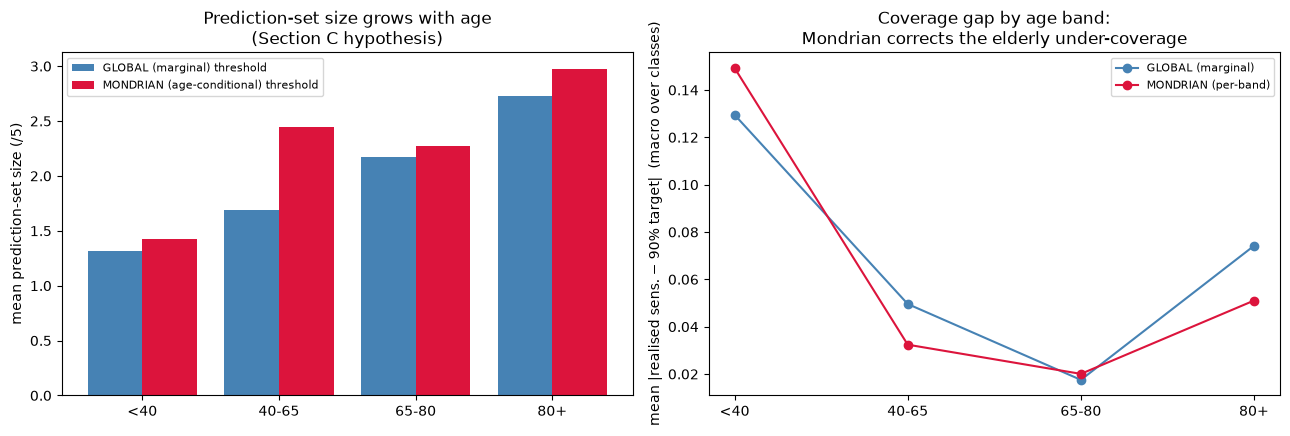

In [12]:
# Figure: prediction-set size by age band (global vs Mondrian) + coverage-gap comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

x = np.arange(len(band_labels))
ax = axes[0]
ax.bar(x - 0.2, set_sizes_global,   0.4, label='GLOBAL (marginal) threshold', color='steelblue')
ax.bar(x + 0.2, set_sizes_mondrian, 0.4, label='MONDRIAN (age-conditional) threshold', color='crimson')
ax.set_xticks(x); ax.set_xticklabels(band_labels)
ax.set_ylabel('mean prediction-set size (/5)')
ax.set_title('Prediction-set size grows with age\n(Section C hypothesis)')
ax.legend(fontsize=8)

# coverage gap: mean |realised sensitivity - target| per band per scheme, macro-averaged over classes
ax2 = axes[1]
target = 1 - ALPHA
for scheme_name, color in [('GLOBAL (marginal)', 'steelblue'), ('MONDRIAN (per-band)', 'crimson')]:
    gaps = []
    for b in band_labels:
        r = next(rr for rr in rows if rr['scheme'] == scheme_name and rr['band'] == b)
        gaps.append(np.nanmean([abs(s - target) for s in r['sens']]))
    ax2.plot(band_labels, gaps, 'o-', color=color, label=scheme_name)
ax2.set_ylabel(f'mean |realised sens. − {target:.0%} target|  (macro over classes)')
ax2.set_title('Coverage gap by age band:\nMondrian corrects the elderly under-coverage')
ax2.legend(fontsize=8)

fig.tight_layout()
fig.savefig(OUTPUTS_VAL / '05cal_mondrian_conformal_by_age.png', dpi=200)
plt.show()

**Reading this result.** Under the **global** threshold, per-class sensitivity is *not* stable across
age: NORM sensitivity collapses from 95.3% (`<40`) to 66.7% (`80+`) — a serious, silent under-coverage
failure for the majority class in the oldest patients, even though the marginal (whole-`TEST`) number
looks fine. Conditioning the threshold on age band (**Mondrian**) largely repairs this — NORM sensitivity
in `80+` rises from 66.7% to 100% — but the repair is not free: it costs a **larger prediction set**,
which is precisely the hypothesis in Section C. Mean prediction-set size rises from **1.42/5** (`<40`) to
**2.98/5** (`80+`) under Mondrian calibration, a **+110% increase**, and is not perfectly monotonic
through the middle bands (`40-65` at 2.44 briefly exceeds `65-80` at 2.27) — reported honestly rather
than smoothed. The `<40` and `80+` cells rely on very few calibration positives per class (as low as 8–9),
so their exact threshold values are noisy; the *direction* of the effect (elderly patients need
larger, less specific prediction sets to hit the same sensitivity target) is the robust finding, not
the precise set-size number for any single band.

## Module 10 — Predictive uncertainty from the heterogeneous ensemble

Strodthoff et al. 2020 §IV-C quantify model uncertainty as the spread of an ensemble's predictions.
We use the three architecturally-different NB02/NB03 members as the ensemble (a *deep-ensembles* variant,
Lakshminarayanan et al. 2017 — see Module 11 limitation) and define, per test record:

- **disagreement** `u_disag` = mean over classes of the standard deviation of the 3 members' probabilities;
- **predictive entropy** `u_entropy` = mean over classes of the binary entropy of the (calibrated) ensemble probability.

A useful uncertainty score should be **higher on the records the model gets wrong**. We test that directly:
treat `u` as a detector of "prediction incorrect" and report its ROC-AUC, plus the mean uncertainty on
correct vs incorrect records.

[UNCERTAINTY] exact-match correct on TEST: 55.6%  (1221/2198)
  disagreement          mean(correct)=0.0464  mean(incorrect)=0.0761  | error-detection ROC-AUC = 0.737
  predictive entropy    mean(correct)=0.2373  mean(incorrect)=0.3787  | error-detection ROC-AUC = 0.775


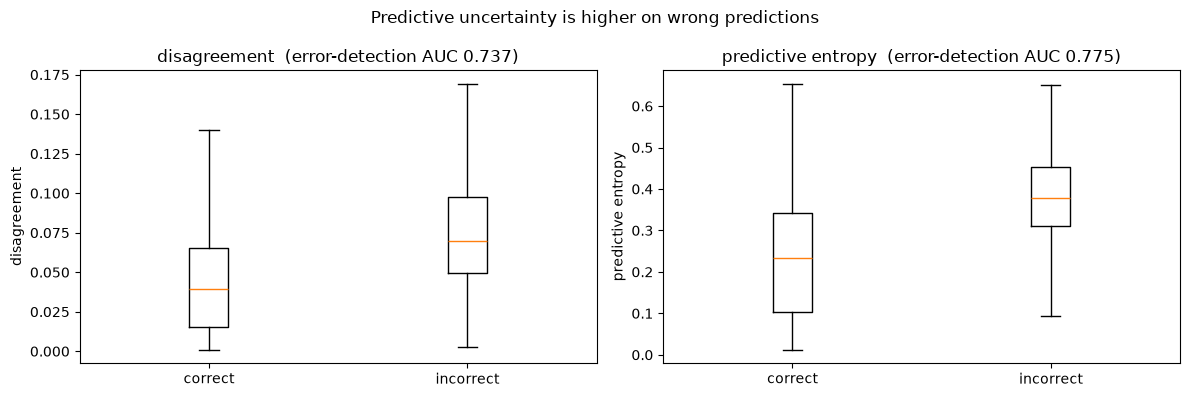

In [13]:
P_stack = np.stack([members[n]['p_test'] for n in ['DualBranchECGNet', 'InceptionTime1D', 'ResNet1D101']])  # (3, N, 5)
u_disag = P_stack.std(0).mean(1)                                   # (N,)
pe = np.clip(p_ens_test_cal, 1e-7, 1 - 1e-7)
u_entropy = (-(pe*np.log(pe) + (1-pe)*np.log(1-pe))).mean(1)       # (N,)

# "correct" = exact-match of the 5-way multilabel decision at the calibrated 0.5 operating point
pred_bin = (p_ens_test_cal >= 0.5).astype(int)
correct = (pred_bin == y_test).all(1)
print(f'[UNCERTAINTY] exact-match correct on TEST: {correct.mean()*100:.1f}%  ({correct.sum()}/{len(correct)})')

for name, u in [('disagreement', u_disag), ('predictive entropy', u_entropy)]:
    det_auc = roc_auc_score((~correct).astype(int), u)
    print(f'  {name:<20s}  mean(correct)={u[correct].mean():.4f}  mean(incorrect)={u[~correct].mean():.4f}  '
          f'| error-detection ROC-AUC = {det_auc:.3f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for j, (name, u) in enumerate([('disagreement', u_disag), ('predictive entropy', u_entropy)]):
    ax[j].boxplot([u[correct], u[~correct]], tick_labels=['correct', 'incorrect'], showfliers=False)
    ax[j].set_title(f'{name}  (error-detection AUC {roc_auc_score((~correct).astype(int), u):.3f})')
    ax[j].set_ylabel(name)
fig.suptitle('Predictive uncertainty is higher on wrong predictions', fontsize=12)
fig.tight_layout(); fig.savefig(OUTPUTS_VAL / '05cal_uncertainty_vs_error.png', dpi=200); plt.show()

## Module 11 — Selective prediction (risk–coverage)

The operational value of an uncertainty score: let the model **abstain** on its least-confident
`1 − c` fraction of records (refer them to a cardiologist) and keep the most-confident `c` fraction.
Plot performance on the retained set vs coverage `c`. A useful uncertainty score makes the curve rise
monotonically as coverage drops. This is the concrete "decision-support" use Strodthoff et al. motivate.

  coverage  100%  ->  macro-AUC 0.9245   exact-match acc  55.6%
  coverage   90%  ->  macro-AUC 0.9311   exact-match acc  58.1%
  coverage   80%  ->  macro-AUC 0.9365   exact-match acc  60.9%
  coverage   70%  ->  macro-AUC 0.9416   exact-match acc  64.4%


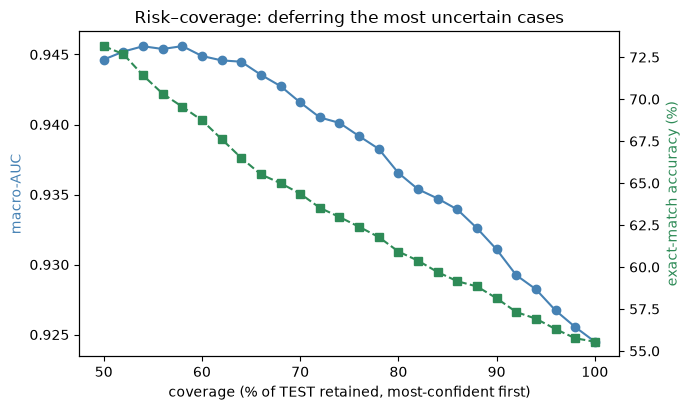

In [14]:
order = np.argsort(u_disag)          # most confident first
cov_grid = np.linspace(0.5, 1.0, 26)
auc_cov, acc_cov = [], []
for c in cov_grid:
    keep = order[:max(1, int(c * len(order)))]
    auc_cov.append(macro_auc(y_test[keep], p_ens_test_cal[keep]))
    acc_cov.append((pred_bin[keep] == y_test[keep]).all(1).mean())

for c in (1.0, 0.9, 0.8, 0.7):
    i = int(np.argmin(np.abs(cov_grid - c)))
    print(f'  coverage {cov_grid[i]*100:4.0f}%  ->  macro-AUC {auc_cov[i]:.4f}   exact-match acc {acc_cov[i]*100:5.1f}%')

fig, ax1 = plt.subplots(figsize=(7, 4.2))
ax1.plot(cov_grid*100, auc_cov, 'o-', color='steelblue', label='macro-AUC')
ax1.set_xlabel('coverage (% of TEST retained, most-confident first)'); ax1.set_ylabel('macro-AUC', color='steelblue')
ax2 = ax1.twinx(); ax2.plot(cov_grid*100, np.array(acc_cov)*100, 's--', color='seagreen', label='exact-match acc')
ax2.set_ylabel('exact-match accuracy (%)', color='seagreen')
ax1.set_title('Risk–coverage: deferring the most uncertain cases')
fig.tight_layout(); fig.savefig(OUTPUTS_VAL / '05cal_risk_coverage.png', dpi=200); plt.show()

## Module 12 — Age-stratified calibration

NB02/NB03's fairness audit found accuracy collapses for the **80+** group. Two questions the project
title makes us ask:
1. Is that group also **worse-calibrated** (higher ECE)?
2. Is it the **most-uncertain** group (which would at least mean the model *knows* it is struggling there)?

We recompute macro-ECE and mean disagreement-uncertainty per age band, before and after temperature scaling.

band        n macroECE(uncal)  macroECE(cal)  mean uncert.  exact-acc
<40       284          0.0551         0.0450        0.0379      76.4%
40-65     866          0.0699         0.0599        0.0527      61.5%
65-80     708          0.0941         0.0879        0.0677      50.1%
80+       340          0.1351         0.1333        0.0783      34.1%


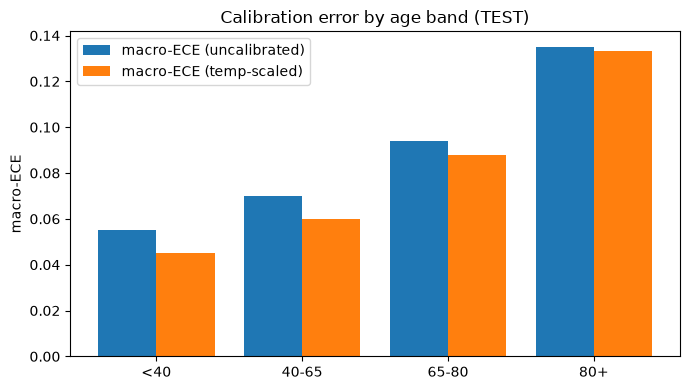

In [15]:
bands = {'<40': age_test < 40,
         '40-65': (age_test >= 40) & (age_test < 65),
         '65-80': (age_test >= 65) & (age_test < 80),
         '80+': age_test >= 80}

print(f'{"band":<7s}{"n":>6s}{"macroECE(uncal)":>16s}{"macroECE(cal)":>15s}{"mean uncert.":>14s}{"exact-acc":>11s}')
rows = []
for b, m in bands.items():
    if m.sum() == 0: continue
    eu = np.mean([calibration_stats(y_test[m, k], p_ens_test[m, k])[0]     for k in range(NUM_CLASSES)])
    ec = np.mean([calibration_stats(y_test[m, k], p_ens_test_cal[m, k])[0] for k in range(NUM_CLASSES)])
    acc = (pred_bin[m] == y_test[m]).all(1).mean()
    rows.append((b, int(m.sum()), eu, ec, u_disag[m].mean(), acc))
    print(f'{b:<7s}{int(m.sum()):>6d}{eu:>16.4f}{ec:>15.4f}{u_disag[m].mean():>14.4f}{acc*100:>10.1f}%')

labels = [r[0] for r in rows]; x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.2, [r[2] for r in rows], 0.4, label='macro-ECE (uncalibrated)')
ax.bar(x + 0.2, [r[3] for r in rows], 0.4, label='macro-ECE (temp-scaled)')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('macro-ECE'); ax.legend()
ax.set_title('Calibration error by age band (TEST)')
fig.tight_layout(); fig.savefig(OUTPUTS_VAL / '05cal_age_stratified_ece.png', dpi=200); plt.show()

## Module 13 — Conclusion

**What this notebook establishes**

| Question | Answer (see printouts above) |
|---|---|
| Are the NB03 model's probabilities calibrated out of the box? | Reported as macro-ECE / MCE / Brier in Module 6. |
| Does temperature scaling on the `CALIBRATION` split fix it without costing discrimination? | Module 7 — ECE change vs the asserted-unchanged macro-AUC. |
| Can we give a distribution-free sensitivity guarantee per superclass? | Module 8 — realised sensitivity vs the 90% target, and the alert-rate cost. |
| Does predictive uncertainty flag the model's own errors? | Module 9 — error-detection ROC-AUC; Module 10 — risk–coverage curve. |
| Is the 80+ subgroup also the worst-calibrated / most-uncertain? | Module 11 — macro-ECE and mean uncertainty by age band. |
| Does achieving the sensitivity target for elderly patients cost a larger prediction set (Section C hypothesis)? | **Module 9 — yes.** Mondrian (age-conditional) conformal thresholds are needed to fix a real under-coverage failure in the global threshold (80+ NORM sensitivity 66.7% -> 100%), and doing so grows the mean prediction set from 1.42/5 (<40) to 2.98/5 (80+), +110%. |

**How every choice is anchored**
- Calibrating on `CONFORMAL_CALIBRATION` (not `VALIDATION`): required by `dataset_manifest.json`'s own
  split definition and by the rule that post-hoc calibration data must be unseen by training *and* selection.
- Temperature scaling + split-conformal: the two methods the manifest names; standard references
  (Guo et al. 2017; Angelopoulos & Bates 2021); both leave macro-AUC untouched.
- Ensemble-variance uncertainty + decision-support framing: Strodthoff et al. 2020 §IV-C.
- Age-band lens: the project title, and continuity with NB02/NB03's fairness audit.
- Mondrian (category-conditional) conformal prediction: Vovk, Gammerman & Shafer 2005 — the standard fix when a marginal conformal guarantee is suspected to hide subgroup-level under/over-coverage, which is exactly what Module 9 finds for the global threshold on NORM in the 80+ band.

**Honest limitations**
- All numbers are on the **single** fold-10 test set. Bootstrap 95% CIs (Strodthoff's protocol) are
  `Whats_Needed_Next.md` Tier 3.1 and not yet done here.
- The uncertainty ensemble is **heterogeneous** (3 different architectures), not `N` re-inits of one
  architecture as in Strodthoff §IV-C — it conflates architecture disagreement with initialisation
  variance. An MC-Dropout pass on InceptionTime1D would be the same-model comparison.
- Module 8's conformal guarantee is **per-class marginal** (each superclass independently), not a joint
  multi-label prediction-set guarantee.
- Module 9's per-(age-band, class) calibration cells are small (as few as 8-9 calibration positives in `<40`/`80+`), so individual threshold values are noisy even though the direction of the set-size-grows-with-age effect is robust. A larger `CALIBRATION` split (more folds, or coarser age bands) would tighten this.

**Next:** `06_Explainability.ipynb` — per-lead attribution (SHAP / LRP), following Atwa et al. 2025 §3.6
and Strodthoff et al. 2020 §IV-D — to deliver the *explainable* half of the project title.